## Imports

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parents[0]))

import scripts.prepare as prepare
import scripts.services as services
import scripts.roi as roi_services
import scripts.bss_pipeline as bss_pl
import scripts.visualization as vis

from scipy.interpolate import make_interp_spline

%load_ext autoreload
%autoreload 2

### fixed variables

In [125]:
N_PC = 10 # discovered by analysis
NFRAMES_OUT = 1200
SCALE_OUT = 0.2
FPS_OUT = 240
N_PEAKS = 5

# VIDEO_PATH_IN = str(Path.cwd().parents[0] / "videos/camp_3/20260525/20260525_1/m/VID_20260525_073740210.mp4")
# VIDEO_PATH_IN = str(Path.cwd().parents[0] / "videos/camp_3/20260526/20260526_1/m/VID_20260526_073704629.mp4")
# VIDEO_PATH_IN = str(Path.cwd().parents[0] / "videos/camp_3/20260527/20260527_1/m/VID_20260527_073900146.mp4")
# VIDEO_PATH_IN = str(Path.cwd().parents[0] / "videos/camp_3/20260528/20260528_1/m/VID_20260528_060712313.mp4")
# VIDEO_PATH_IN = str(Path.cwd().parents[0] / "videos/camp_3/20260529/20260529_1/m/VID_20260529_083217557.mp4")
# VIDEO_PATH_IN = str(Path.cwd().parents[0] / "videos/camp_3/20260530/20260530_1/m/VID_20260530_074908974.mp4")
# VIDEO_PATH_IN = str(Path.cwd().parents[0] / "videos/camp_3/20260531/20260531_1/m/VID_20260531_074058464.mp4")
# VIDEO_PATH_IN = str(Path.cwd().parents[0] / "videos/camp_3/20260601/20260601_1/m/VID_20260601_075037657.mp4")
# VIDEO_PATH_IN = str(Path.cwd().parents[0] / "videos/camp_3/20260602/20260602_1/m/VID_20260602_082954275.mp4")
# VIDEO_PATH_IN = str(Path.cwd().parents[0] / "videos/camp_3/20260603/20260603_1/m/VID_20260603_091531958.mp4")
# VIDEO_PATH_IN = str(Path.cwd().parents[0] / "videos/camp_3/20260604/20260604_1/m/VID_20260604_083531697.mp4")
# VIDEO_PATH_IN = str(Path.cwd().parents[0] / "videos/camp_3/20260605/20260605_1/m/VID_20260605_085321999.mp4")
# VIDEO_PATH_IN = str(Path.cwd().parents[0] / "videos/camp_3/20260606/20260606_1/m/VID_20260606_073857092.mp4")
# VIDEO_PATH_IN = str(Path.cwd().parents[0] / "videos/camp_3/20260607/20260607_1/m/VID_20260607_081304960.mp4")

# VIDEO_PATH_IN = str(Path.cwd().parents[0] / "videos/camp_3/20260525/20260525_2/m/VID_20260525_073831392.mp4")
# VIDEO_PATH_IN = str(Path.cwd().parents[0] / "videos/camp_3/20260526/20260526_2/m/VID_20260526_073755265.mp4")
# VIDEO_PATH_IN = str(Path.cwd().parents[0] / "videos/camp_3/20260527/20260527_2/m/VID_20260527_074035158.mp4")
# VIDEO_PATH_IN = str(Path.cwd().parents[0] / "videos/camp_3/20260528/20260528_2/m/VID_20260528_060627096.mp4")
# VIDEO_PATH_IN = str(Path.cwd().parents[0] / "videos/camp_3/20260529/20260529_2/m/VID_20260529_083140178.mp4")
# VIDEO_PATH_IN = str(Path.cwd().parents[0] / "videos/camp_3/20260530/20260530_2/m/VID_20260530_074702260.mp4")
# VIDEO_PATH_IN = str(Path.cwd().parents[0] / "videos/camp_3/20260531/20260531_2/m/VID_20260531_074018077.mp4")
# VIDEO_PATH_IN = str(Path.cwd().parents[0] / "videos/camp_3/20260601/20260601_2/m/VID_20260601_074946932.mp4")
# VIDEO_PATH_IN = str(Path.cwd().parents[0] / "videos/camp_3/20260602/20260602_2/m/VID_20260602_082906225.mp4")
# VIDEO_PATH_IN = str(Path.cwd().parents[0] / "videos/camp_3/20260603/20260603_2/m/VID_20260603_091456724.mp4")
# VIDEO_PATH_IN = str(Path.cwd().parents[0] / "videos/camp_3/20260604/20260604_2/m/VID_20260604_083609177.mp4")
# VIDEO_PATH_IN = str(Path.cwd().parents[0] / "videos/camp_3/20260605/20260605_2/m/VID_20260605_085242545.mp4")
# VIDEO_PATH_IN = str(Path.cwd().parents[0] / "videos/camp_3/20260606/20260606_2/m/VID_20260606_073814392.mp4")
VIDEO_PATH_IN = str(Path.cwd().parents[0] / "videos/camp_3/20260607/20260607_2/m/VID_20260607_081227742.mp4")


VIDEO_NAME = VIDEO_PATH_IN.split("/")[-1]
VIDEO_PATH_OUT = str(Path.cwd().parents[0] / "outputs/misc" / VIDEO_NAME)

ROIS = roi_services.load_rois(str(Path.cwd().parents[0] / "rois/rois.json"))
VIDEO_ROI = ROIS[VIDEO_NAME]

video_in_info = services.get_video_info(VIDEO_PATH_IN)
video_in_info

{'path': '/home/reginaldo/workspaces/PythonLanguage/marajo/videos/camp_3/20260607/20260607_2/m/VID_20260607_081227742.mp4',
 'fps': 29.931310896541422,
 'width': 1080,
 'height': 1920,
 'frames': 2636,
 'duration': 88.07,
 'shape': (1920, 1080, 3)}

### pre-processing

In [126]:
prepare.pre_processing(VIDEO_PATH_IN, VIDEO_PATH_OUT, NFRAMES_OUT, FPS_OUT, SCALE_OUT, VIDEO_ROI)

In [127]:
video_out_info = services.get_video_info(VIDEO_PATH_OUT)
video_out_info

{'path': '/home/reginaldo/workspaces/PythonLanguage/marajo/outputs/misc/VID_20260607_081227742.mp4',
 'fps': 240.0,
 'width': 190,
 'height': 136,
 'frames': 1200,
 'duration': 5.0,
 'shape': (136, 190, 3)}

### computer vision

In [128]:
unmixed, winvmix, w, h = bss_pl.run_pipeline(VIDEO_PATH_OUT, N_PC)

In [129]:
fft_data = bss_pl.compute_fft_for_components(unmixed, video_out_info["fps"], range(N_PC))
peaks_info = bss_pl.get_highest_peak_frequencies(fft_data, N_PEAKS)

In [130]:
amp = 0
freq = 0
source = 0
for k, v in peaks_info.items():    
    if v['highest_freq'] > 1 and v['highest_amp'] > amp:
        amp = v['highest_amp']
        freq = v['highest_freq']
        source = k
print(f"freq: {round(freq, 2)} | amp: {round(amp, 2)} | source = {source}")

freq: 2.8 | amp: 110.89 | source = 9


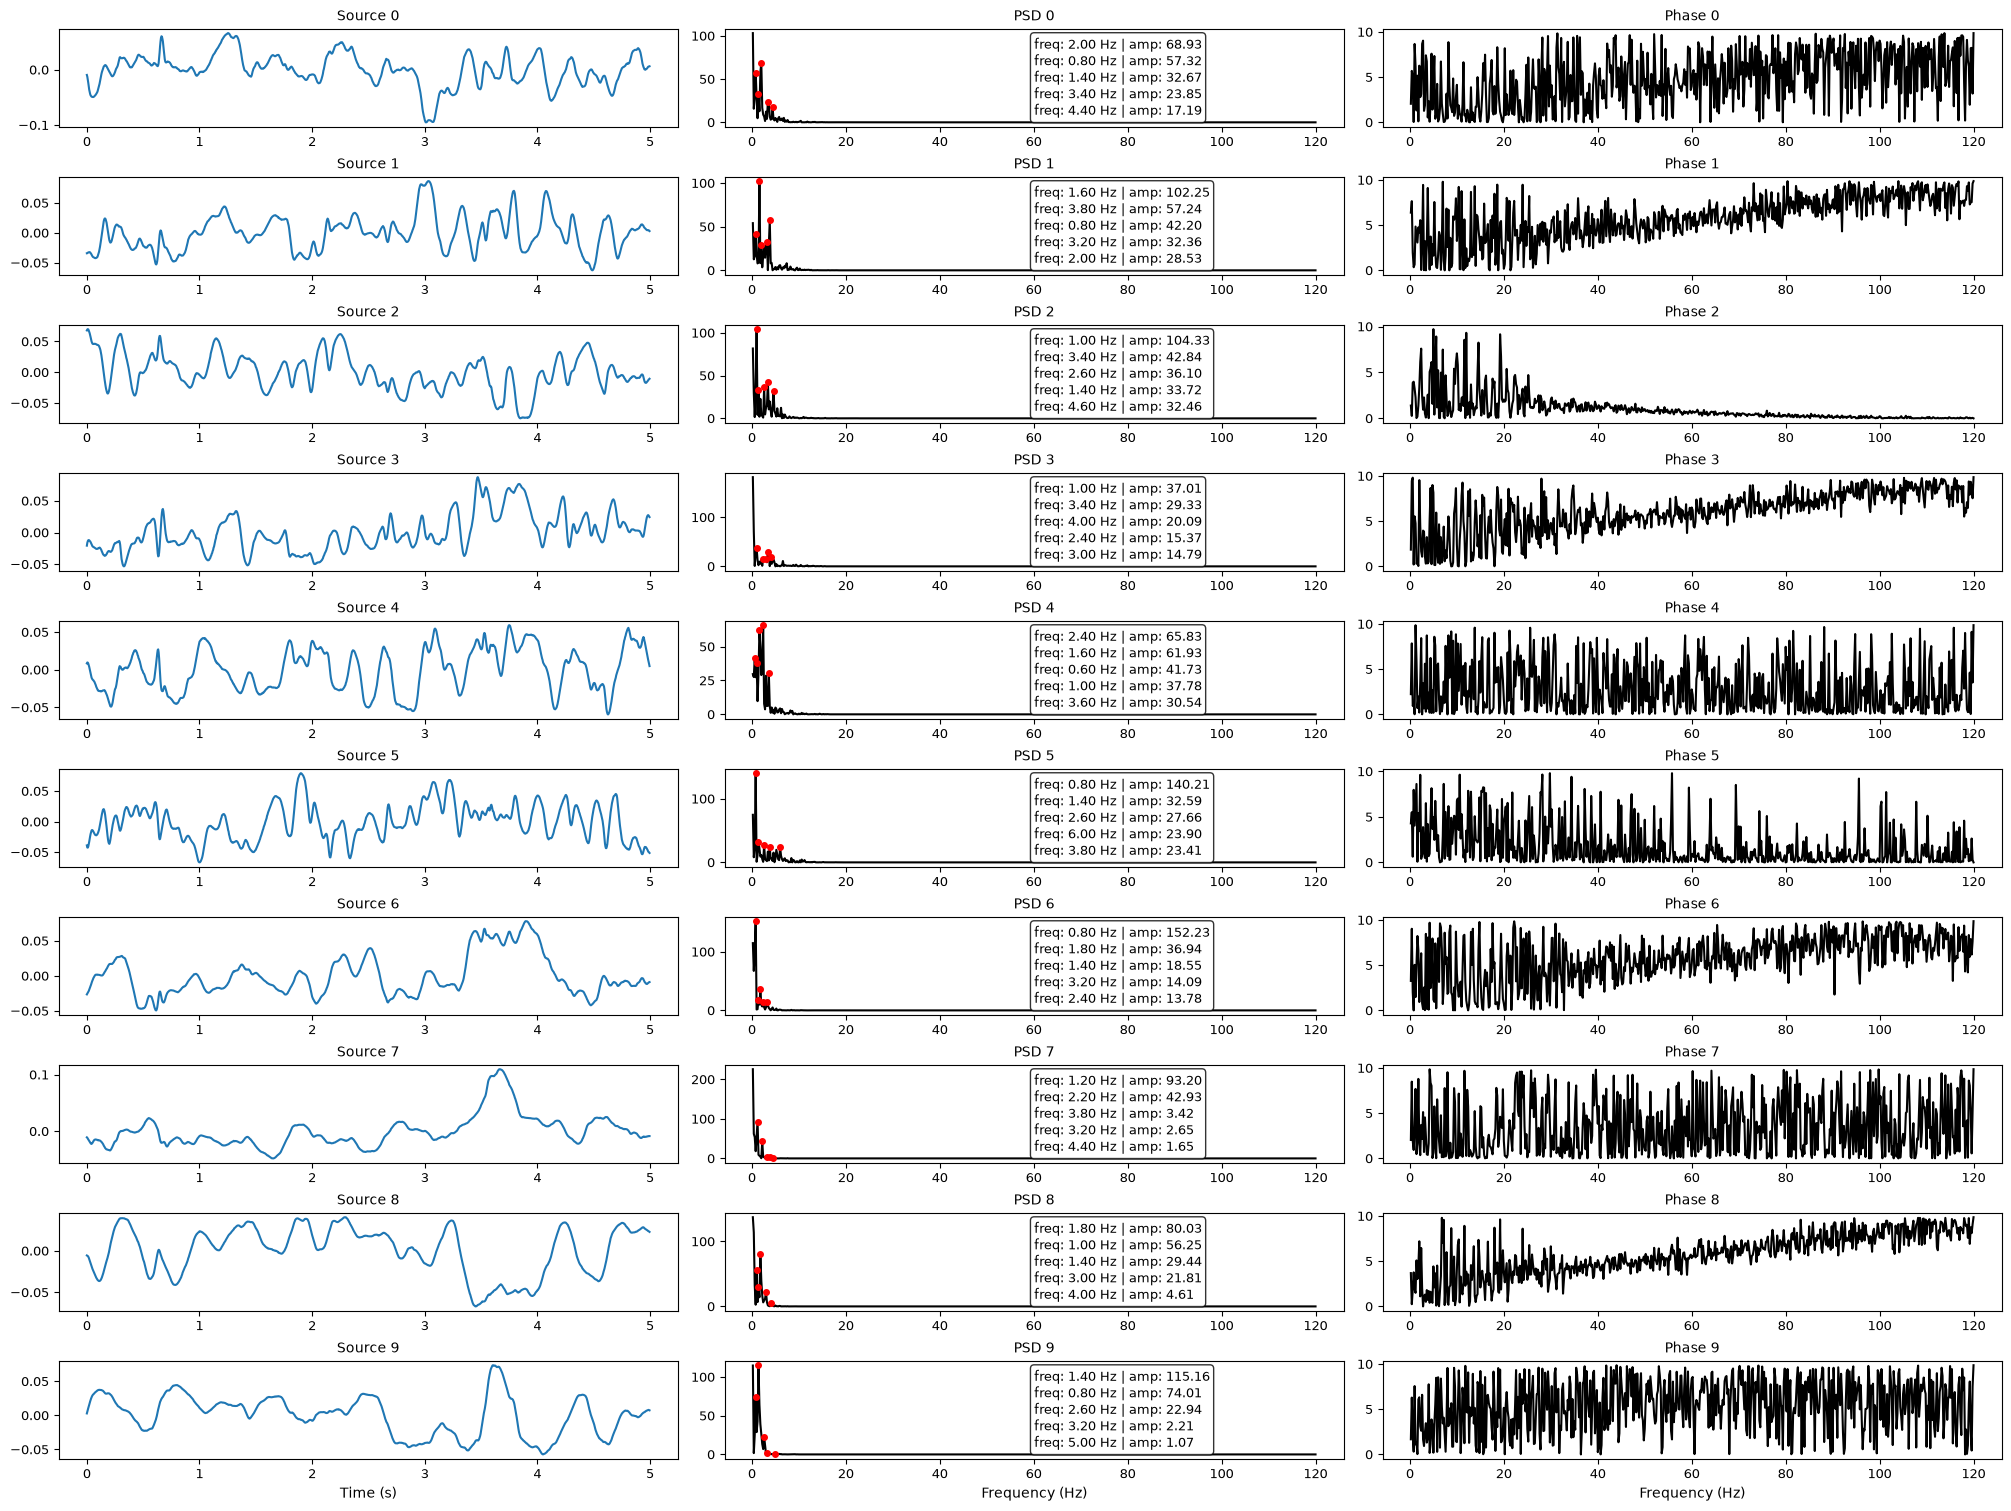

In [88]:
vis.plot_source_psd_phase(fft_data, peaks_info, video_out_info, range(N_PC), save = True, name = f"p2_sfp_{VIDEO_NAME}")

In [ ]:
vis.plot_source_psd_phase(fft_data, peaks_info, video_out_info, [9], 20, 5, save = True, name = "p2_out_{VIDEO_NAME}")

In [ ]:
mode_shapes = bss_pl.compute_mode_shapes(winvmix, w, N_PC, range(N_PC))

In [ ]:
vis.plot_mode_shapes(mode_shapes, video_out_info['height'], video_out_info['width'], range(N_PC), save = True)

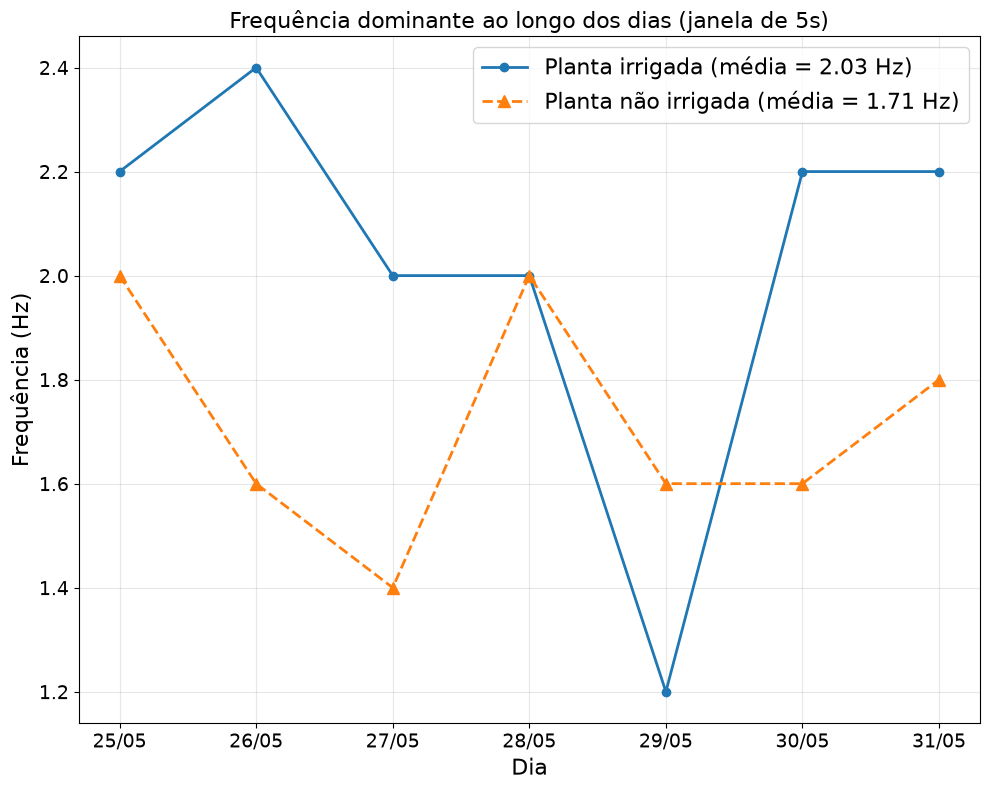

In [22]:
import matplotlib.pyplot as plt

dias = ["25/05", "26/05", "27/05", "28/05", "29/05", "30/05", "31/05"]

planta_irrigada = [2.2, 2.4, 2.0, 2.0, 1.2, 2.2, 2.2]
planta_nao_irrigada = [2.0, 1.6, 1.4, 2.0, 1.6, 1.6, 1.8]
media_irrigada = np.mean(planta_irrigada)
media_nao_irrigada = np.mean(planta_nao_irrigada)

plt.figure(figsize=(10, 8))

plt.plot(dias, planta_irrigada, marker="o", linewidth=2, label=f"Planta irrigada (média = {media_irrigada:.2f} Hz)")

plt.plot(dias, planta_nao_irrigada, marker="^", markersize = 8, linestyle = "--", linewidth=2, label=f"Planta não irrigada (média = {media_nao_irrigada:.2f} Hz)")

plt.xlabel("Dia", fontsize=16)
plt.ylabel("Frequência (Hz)", fontsize=16)
plt.title("Frequência dominante ao longo dos dias (janela de 5s)", fontsize=16)

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.legend(fontsize=16)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("frequencias_plantas.pdf", format="pdf", bbox_inches="tight")

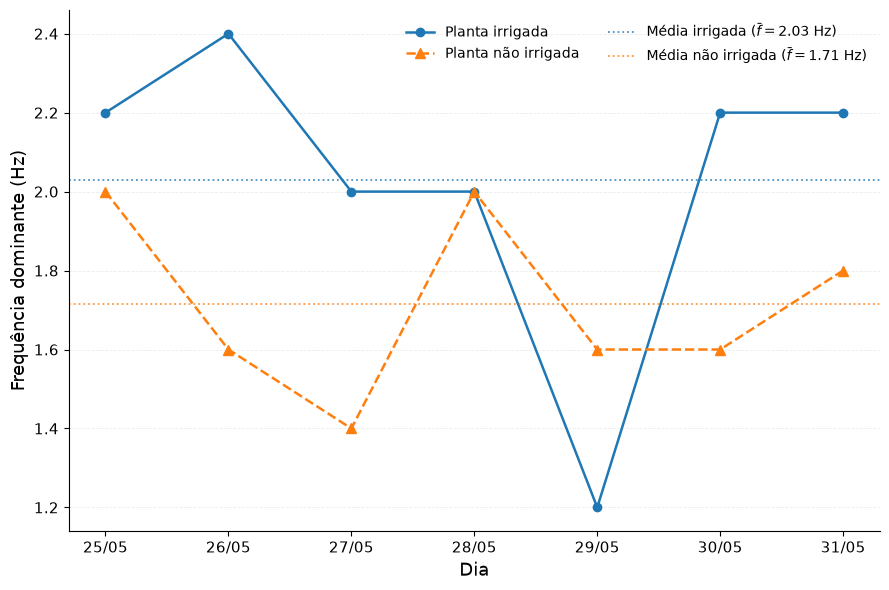

In [1]:
import numpy as np
import matplotlib.pyplot as plt

dias = ["25/05", "26/05", "27/05", "28/05", "29/05", "30/05", "31/05"]

planta_irrigada = [2.2, 2.4, 2.0, 2.0, 1.2, 2.2, 2.2]
planta_nao_irrigada = [2.0, 1.6, 1.4, 2.0, 1.6, 1.6, 1.8]

media_irrigada = np.mean(planta_irrigada)
media_nao_irrigada = np.mean(planta_nao_irrigada)

fig, ax = plt.subplots(figsize=(9, 6))

# Séries temporais
line1, = ax.plot(
    dias,
    planta_irrigada,
    marker="o",
    markersize=6,
    linewidth=1.8,
    label="Planta irrigada",
)

line2, = ax.plot(
    dias,
    planta_nao_irrigada,
    marker="^",
    markersize=7,
    linestyle="--",
    linewidth=1.8,
    label="Planta não irrigada",
)

# Médias
ax.axhline(
    media_irrigada,
    linestyle=":",
    linewidth=1.3,
    alpha=0.8,
    color=line1.get_color(),
    label=rf"Média irrigada ($\bar{{f}}={media_irrigada:.2f}$ Hz)",
)

ax.axhline(
    media_nao_irrigada,
    linestyle=":",
    linewidth=1.3,
    alpha=0.8,
    color=line2.get_color(),
    label=rf"Média não irrigada ($\bar{{f}}={media_nao_irrigada:.2f}$ Hz)",
)

# Eixos
ax.set_xlabel("Dia", fontsize=13)
ax.set_ylabel("Frequência dominante (Hz)", fontsize=13)

ax.tick_params(axis="both", labelsize=11)

# Grade discreta apenas no eixo y
ax.grid(
    axis="y",
    linestyle="--",
    linewidth=0.6,
    alpha=0.25,
)

# Remove bordas superior e direita
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Legenda
ax.legend(
    fontsize=10,
    frameon=False,
    ncol=2,
)

fig.tight_layout()

fig.savefig(
    "frequencias_plantas_2.pdf",
    format="pdf",
    bbox_inches="tight",
)

plt.show()